# 多干预归因：GACRNet + IDCIO on EconML Multi-Attribution

本 notebook 用软件公司客户激励数据演示多干预归因与个体化组合干预推荐。数据包含 Tech Support 和 Discount 两类激励、客户画像特征以及后续 Revenue；目标是估计不同客户的原子干预效应、评估排序型策略收益，并通过 IDCIO 求解每个客户的最优干预组合。


In [1]:
import sys
import warnings
from pathlib import Path

for parent in [Path.cwd(), *Path.cwd().parents]:
    src_dir = parent / "src"
    if (src_dir / "causalmt").exists():
        sys.path.insert(0, str(src_dir))
        break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from causalmt import GACRNet, IDCIO
from causalmt.metrics import ate_error, pehe, policy_risk

warnings.simplefilter("ignore")

plt.rcParams["font.sans-serif"] = [
    "PingFang SC", "Heiti TC", "STHeiti", "Microsoft YaHei", "SimHei", "sans-serif"
]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

## 1. 数据

数据集与 EconML 案例一致，包含约 2,000 个客户：

| Feature | Role | Meaning |
| :--- | :--- | :--- |
| `Global Flag`, `Major Flag`, `SMC Flag`, `Commercial Flag` | W | 客户类型控制变量 |
| `IT Spend`, `Employee Count`, `PC Count` | W | IT 支出、员工数、PC 数 |
| `Size` | X | 客户年度收入规模，用于异质性分析 |
| `Tech Support`, `Discount` | T | 两个二元激励干预 |
| `Revenue` | Y | 激励后一年软件购买收入 |

In [2]:
# 与 EconML notebook 相同的官方数据入口
file_url = "https://raw.githubusercontent.com/py-why/EconML/refs/heads/data/datasets/ROI/multi_attribution_sample.csv"
multi_data = pd.read_csv(file_url)

print(f"rows={multi_data.shape[0]}, columns={multi_data.shape[1]}")
multi_data.head()

rows=2000, columns=11


,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue
0,1,0,1,0,45537,26,26,152205,0,1,17688.36300
1,0,0,1,1,20842,107,70,159038,0,1,14981.43559
2,0,0,0,1,82171,10,7,264935,1,1,32917.13894
3,0,0,0,0,30288,40,39,77522,1,1,14773.76855
4,0,0,1,0,25930,37,43,91446,1,1,17098.69823


In [3]:
# 与 EconML 示例一致的估计器输入定义
T_bin = multi_data[["Tech Support", "Discount"]]  # multiple interventions, or treatments
Y = multi_data["Revenue"]                         # outcome
X = multi_data[["Size"]]                          # heterogeneity feature
W = multi_data.drop(columns=["Tech Support", "Discount", "Revenue", "Size"])


def treat_map(t):
    return np.dot(t, 2 ** np.arange(t.shape[0]))


T = np.apply_along_axis(treat_map, 1, T_bin.to_numpy()).astype(int)
all_treatment_names = np.array(["None", "Tech Support", "Discount", "Tech Support & Discount"])
atomic_treatment_names = ["Tech Support", "Discount"]

multi_data[["Size", "Tech Support", "Discount"]].groupby(
    by=["Tech Support", "Discount"], as_index=False
).mean().astype(int)

,Tech Support,Discount,Size
0,0,0,70943
1,0,1,96466
2,1,0,108978
3,1,1,171466


EconML 案例中的合成数据真值函数为：

$$
\tau(x) = (5000 + 0.02 \cdot Size) \cdot I_{TechSupport} + (0.05 \cdot Size) \cdot I_{Discount}
$$

因此 Tech Support 与 Discount 的真效应可以从 `Size` 直接计算；组合干预在该数据里是两个原子效应相加。

In [4]:
def TE_fn(size):
    size = np.asarray(size).reshape(-1, 1)
    return np.hstack([5000 + 0.02 * size, 0.05 * size]).astype(np.float32)


def cost_fn(df):
    # EconML 案例设定：Tech Support 成本 = 100 * PC Count，Discount 固定成本 = 7000
    tech_support_cost = df[["PC Count"]].to_numpy(dtype=np.float32) * 100
    discount_cost = np.full((df.shape[0], 1), 7000.0, dtype=np.float32)
    return np.hstack([tech_support_cost, discount_cost]).astype(np.float32)


true_atomic_te = TE_fn(X.values)  # columns: Tech Support, Discount
true_te_by_t = np.column_stack([
    np.zeros(len(multi_data), dtype=np.float32),
    true_atomic_te[:, 0],
    true_atomic_te[:, 1],
    true_atomic_te.sum(axis=1),
]).astype(np.float32)

cost_atomic = cost_fn(multi_data)
cost_by_t = np.column_stack([
    np.zeros(len(multi_data), dtype=np.float32),
    cost_atomic[:, 0],
    cost_atomic[:, 1],
    cost_atomic.sum(axis=1),
]).astype(np.float32)

factual_effect = true_te_by_t[np.arange(len(T)), T]
mu0_true = Y.to_numpy(dtype=np.float32) - factual_effect
y_potential_true = (mu0_true[:, None] + true_te_by_t).astype(np.float32)

pd.DataFrame(
    {
        "Treatment": atomic_treatment_names + ["Tech Support & Discount"],
        "True ATE": [true_atomic_te[:, 0].mean(), true_atomic_te[:, 1].mean(), true_te_by_t[:, 3].mean()],
    }
)

,Treatment,True ATE
0,Tech Support,7263.183105
1,Discount,5657.956055
2,Tech Support & Discount,12921.137695


## 2. 构造 CausalMT 训练数据

`GACRNet` 先按原训练脚本参数学习原子干预：`0=None`、`1=Tech Support`、`2=Discount`。同时接受两个干预的客户样本留给 IDCIO，用于学习组合干预的交互残差。

In [5]:
BINARY_COLS = ["Global Flag", "Major Flag", "SMC Flag", "Commercial Flag"]
RAW_CONT_COLS = ["IT Spend", "Employee Count", "PC Count", "Size"]
LOG_CONT_COLS = ["logIT", "logEmp", "logPC", "logSize"]

feature_df = multi_data[BINARY_COLS].astype(np.float32).copy()
for raw_col, log_col in zip(RAW_CONT_COLS, LOG_CONT_COLS):
    feature_df[log_col] = np.log1p(multi_data[raw_col]).astype(np.float32)

x_all = feature_df.to_numpy(dtype=np.float32)
y_all = Y.to_numpy(dtype=np.float32)

atomic_mask = T != 3
combined_mask = T == 3
atomic_rows = np.flatnonzero(atomic_mask)
combined_rows = np.flatnonzero(combined_mask)

print(f"原子干预样本: {len(atomic_rows)}")
print(f"组合干预样本: {len(combined_rows)}")
print(f"原子干预分布: {dict(zip(*np.unique(T[atomic_rows], return_counts=True)))}")
print(f"特征列: {list(feature_df.columns)}")

原子干预样本: 1456
组合干预样本: 544
原子干预分布: {0: 517, 1: 462, 2: 477}
特征列: ['Global Flag', 'Major Flag', 'SMC Flag', 'Commercial Flag', 'logIT', 'logEmp', 'logPC', 'logSize']


## 3. 训练/测试切分与标准化

二元特征保持 0/1，连续特征使用训练集统计量标准化；`Revenue` 也只用训练集拟合标准化器。组合干预样本使用相同标准化器，避免数据尺度不一致。

In [6]:
train_pos, test_pos = train_test_split(
    np.arange(len(atomic_rows)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=T[atomic_rows],
)
row_tr = atomic_rows[train_pos]
row_te = atomic_rows[test_pos]

n_binary = len(BINARY_COLS)
x_scaler = StandardScaler()


def scale_features(x, *, fit=False):
    x = np.asarray(x, dtype=np.float32)
    cont = x[:, n_binary:]
    cont_scaled = x_scaler.fit_transform(cont) if fit else x_scaler.transform(cont)
    return np.hstack([x[:, :n_binary], cont_scaled]).astype(np.float32)


X_tr = scale_features(x_all[row_tr], fit=True)
X_te = scale_features(x_all[row_te])
t_tr = T[row_tr]
t_te = T[row_te]
y_tr = y_all[row_tr]
y_te = y_all[row_te]

y_scaler = StandardScaler()
y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1)).ravel().astype(np.float32)
y_te_s = y_scaler.transform(y_te.reshape(-1, 1)).ravel().astype(np.float32)
y_mean = float(y_scaler.mean_[0])
y_std = float(y_scaler.scale_[0])

X_combined = scale_features(x_all[combined_rows])
y_combined_s = y_scaler.transform(y_all[combined_rows].reshape(-1, 1)).ravel().astype(np.float32)

print(f"train={X_tr.shape}, test={X_te.shape}, combined={X_combined.shape}")

train=(1164, 8), test=(292, 8), combined=(544, 8)


## 4. 训练多干预 GACRNet

In [7]:
est = GACRNet(
    num_treatments=3,          # 0=None, 1=Tech Support, 2=Discount
    backbone="mlp",
    head="uplift",
    routing="self",            # 对齐原训练脚本的 self-attention routing
    hidden_dim=200,
    head_hidden=100,
    dropout=0.2,
    use_mmd=True,
    mmd_weight=1.0,
    use_tarreg=True,
    tarreg_ratio=2.0,
    epochs=200,
    batch_size=256,
    lr=1e-3,
    epsilon_clip=0.01,
    early_stopping_patience=20,
    verbose=False,
    random_state=RANDOM_STATE,
)
est.fit(X_tr, t_tr, y_tr_s)
print("原子模型参数: epochs=200, batch_size=256, routing=self, dropout=0.2, tarreg_ratio=2.0, epsilon_clip=0.01")
print(f"最佳验证集损失 {est.history_['best_val_loss']:.4f} @ epoch {est.history_['best_epoch']}")

原子模型参数: epochs=200, batch_size=256, routing=self, dropout=0.2, tarreg_ratio=2.0, epsilon_clip=0.01
最佳验证集损失 1.2819 @ epoch 194


## 5. 指标计算

指标沿用原 notebook：对两个原子干预分别计算 PEHE 和 ATE error。这里还补充 `policy_risk`，用于评估基于预测潜在结果选择原子干预时与真值最优原子策略的差距。

In [8]:
po_te_s = est.predict_potential_outcomes(X_te)
po_te = po_te_s * y_std + y_mean
cate_pred = (po_te_s[:, 1:3] - po_te_s[:, [0]]) * y_std
cate_true = true_atomic_te[row_te]

metrics_df = pd.DataFrame(
    [
        {
            "Treatment": name,
            "ATE_pred": cate_pred[:, j].mean(),
            "ATE_true": cate_true[:, j].mean(),
            "ATE_error": ate_error(cate_pred[:, j], cate_true[:, j]),
            "PEHE": pehe(cate_pred[:, j], cate_true[:, j]),
        }
        for j, name in enumerate(atomic_treatment_names)
    ]
)

true_po_atomic = y_potential_true[row_te, :3]
atomic_policy_risk = policy_risk(po_te, true_po_atomic, objective="max")
print(f"Policy risk among atomic interventions: {atomic_policy_risk:.3f}")
metrics_df

Policy risk among atomic interventions: 13.000


,Treatment,ATE_pred,ATE_true,ATE_error,PEHE
0,Tech Support,6657.997070,6861.546387,203.549316,459.638947
1,Discount,4458.289551,4653.865723,195.576172,714.971741


## 6. 异质性分析：Policy Curve

不再查看 CATE 分布。这里按预测 CATE 从高到低排序，观察前 top-k% 客户的真实平均效应。曲线越接近 Oracle，说明模型越能把高收益客户排到前面。

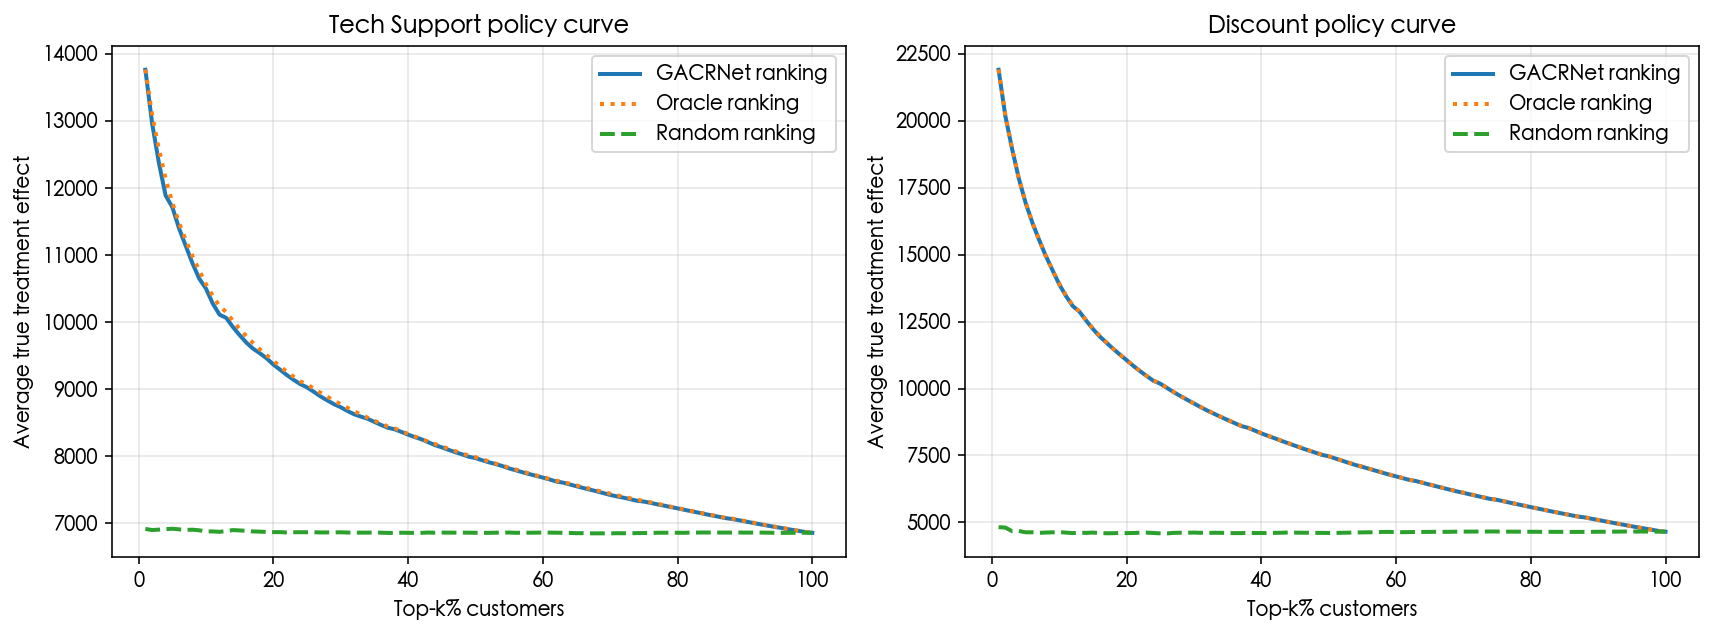

,Treatment,Top 20% by model,Top 20% oracle,Random 20%
0,Tech Support,9368.739407,9423.856992,6871.745636
1,Discount,11059.641949,11059.643008,4600.875988


In [9]:
def policy_curve_values(score, true_effect, k_grid):
    order = np.argsort(score)[::-1]
    true_sorted = np.asarray(true_effect)[order]
    cumulative = np.cumsum(true_sorted) / np.arange(1, len(true_sorted) + 1)
    counts = np.maximum(1, np.ceil(k_grid * len(true_sorted)).astype(int))
    return cumulative[counts - 1]


rng = np.random.default_rng(RANDOM_STATE)
k_grid = np.linspace(0.01, 1.0, 100)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
policy_rows = []

for j, (ax, name) in enumerate(zip(axes, atomic_treatment_names)):
    model_curve = policy_curve_values(cate_pred[:, j], cate_true[:, j], k_grid)
    oracle_curve = policy_curve_values(cate_true[:, j], cate_true[:, j], k_grid)
    random_curve = np.mean(
        [policy_curve_values(rng.permutation(cate_pred[:, j]), cate_true[:, j], k_grid) for _ in range(100)],
        axis=0,
    )

    ax.plot(k_grid * 100, model_curve, linewidth=2, label="GACRNet ranking")
    ax.plot(k_grid * 100, oracle_curve, linewidth=2, linestyle=":", label="Oracle ranking")
    ax.plot(k_grid * 100, random_curve, linewidth=2, linestyle="--", label="Random ranking")
    ax.set_title(f"{name} policy curve")
    ax.set_xlabel("Top-k% customers")
    ax.set_ylabel("Average true treatment effect")
    ax.grid(alpha=0.3)
    ax.legend()

    top20_idx = int(np.searchsorted(k_grid, 0.20))
    policy_rows.append(
        {
            "Treatment": name,
            "Top 20% by model": model_curve[top20_idx],
            "Top 20% oracle": oracle_curve[top20_idx],
            "Random 20%": random_curve[top20_idx],
        }
    )

plt.tight_layout()
plt.show()

pd.DataFrame(policy_rows)

## 7. IDCIO 学习组合干预并推荐个体最优策略

IDCIO 使用 GACRNet 的原子效应作为对角项，再用组合干预样本学习 Tech Support × Discount 的交互项。推荐阶段求解 QUBO：

$$
\max_z\; \tau_1(x) z_1 + \tau_2(x) z_2 + \tau_{12}(x) z_1z_2 - c_1(x)z_1 - c_2(x)z_2
$$

其中成本沿用 EconML 案例：`Tech Support = 100 * PC Count`，`Discount = 7000`。

In [10]:
rec = IDCIO.from_estimator(
    atomic_estimator=est,
    interaction_hidden=(100, 50),
    interaction_dropout=0.0,
    epochs=200,
    batch_size=32,
    lr=1e-3,
    early_stopping_patience=20,
    verbose=False,
    random_state=RANDOM_STATE,
)
print("交互模型参数: epochs=200, batch_size=32, hidden=(100, 50), dropout=0.0")
rec.fit_interaction(
    X_combined,
    y_combined_s,
    treatment_pairs=[(0, 1)],  # IDCIO 内部 0=Tech Support, 1=Discount
)

interaction_pred = rec.predict_interactions(X_te)[(0, 1)] * y_std
print(f"Predicted interaction mean: {interaction_pred.mean():.3f}")
print(f"Predicted interaction RMSE vs additive truth: {np.sqrt(np.mean(interaction_pred ** 2)):.3f}")

交互模型参数: epochs=200, batch_size=32, hidden=(100, 50), dropout=0.0
Predicted interaction mean: 585.254
Predicted interaction RMSE vs additive truth: 1104.719


In [11]:
# IDCIO 的效应是在标准化 Revenue 尺度上，成本也需要除以 y_std 对齐尺度
test_costs = cost_atomic[row_te] / y_std
actions = rec.recommend(
    X_te,
    costs=test_costs,
    method="exhaustive",
    maximize=True,
)
recommended_t = actions[:, 0] + 2 * actions[:, 1]

rec_counts = pd.Series(all_treatment_names[recommended_t]).value_counts().reindex(all_treatment_names, fill_value=0)
rec_summary = pd.DataFrame(
    {
        "Recommended treatment": rec_counts.index,
        "Count": rec_counts.values,
        "Share": rec_counts.values / len(recommended_t),
    }
)
rec_summary

,Recommended treatment,Count,Share
0,None,75,0.256849
1,Tech Support,152,0.520548
2,Discount,7,0.023973
3,Tech Support & Discount,58,0.198630


In [12]:
true_roi = true_te_by_t[row_te] - cost_by_t[row_te]
current_t = T[row_te]
oracle_t = true_roi.argmax(axis=1)

policy_eval = pd.DataFrame(
    [
        {"Policy": "IDCIO recommended", "ROI": true_roi[np.arange(len(row_te)), recommended_t].sum()},
        {"Policy": "Current historical", "ROI": true_roi[np.arange(len(row_te)), current_t].sum()},
        {"Policy": "All investments", "ROI": true_roi[:, 3].sum()},
        {"Policy": "Ground-truth oracle", "ROI": true_roi[np.arange(len(row_te)), oracle_t].sum()},
    ]
)
policy_eval["Mean ROI per customer"] = policy_eval["ROI"] / len(row_te)
policy_eval["ROI (% of baseline Y)"] = policy_eval["ROI"] / mu0_true[row_te].sum() * 100
policy_eval

,Policy,ROI,Mean ROI per customer,ROI (% of baseline Y)
0,IDCIO recommended,1.029775e+06,3526.627197,48.547321
1,Current historical,1.475393e+04,50.527149,0.695554
2,All investments,-2.916998e+05,-998.971741,-13.751781
3,Ground-truth oracle,1.035056e+06,3544.712402,48.796280


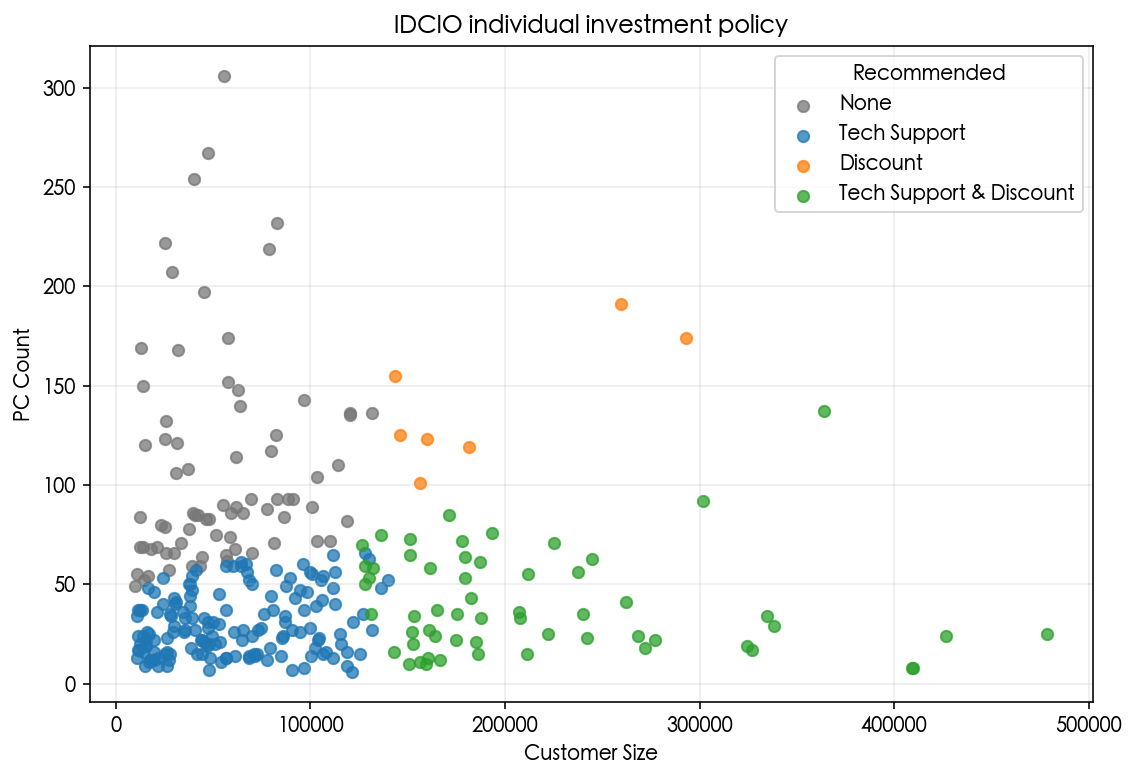

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {
    "None": "#777777",
    "Tech Support": "#1f77b4",
    "Discount": "#ff7f0e",
    "Tech Support & Discount": "#2ca02c",
}
plot_df = pd.DataFrame(
    {
        "Size": multi_data.loc[row_te, "Size"].to_numpy(),
        "PC Count": multi_data.loc[row_te, "PC Count"].to_numpy(),
        "Recommended": all_treatment_names[recommended_t],
    }
)

for label in all_treatment_names:
    mask = plot_df["Recommended"] == label
    ax.scatter(
        plot_df.loc[mask, "Size"],
        plot_df.loc[mask, "PC Count"],
        s=32,
        alpha=0.75,
        color=colors[label],
        label=label,
    )

ax.set_xlabel("Customer Size")
ax.set_ylabel("PC Count")
ax.set_title("IDCIO individual investment policy")
ax.grid(alpha=0.25)
ax.legend(title="Recommended")
plt.tight_layout()
plt.show()